In [304]:
import numpy as np
import pandas as pd
import sqlite3
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score




1.read data from csv

In [305]:
#pd = pd.read_csv(path)

2.save data to sqlite

In [306]:
conn = sqlite3.connect("./data/data.db")
#pd.to_sql("data", conn, if_exists="replace", index=False)

3.Load data

In [307]:
df = pd.read_sql_query("SELECT * FROM data", conn)

4.clean the data

In [308]:
print("="*50)
print("Shape of the data:")
print(df.shape)
print("="*50)

Shape of the data:
(7043, 21)


In [309]:
print("="*50)
print("Data types of the columns:")
print(df.dtypes)
print("="*50)

Data types of the columns:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object


In [310]:
df = df.replace(r'^\s*$', np.nan, regex=True)

In [311]:
print("="*50)
print("Unique values:")
print(df.nunique())
print("="*50)

Unique values:
customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6530
Churn                  2
dtype: int64


In [312]:
print("="*50)
print("Null values:")
print(df.isnull().sum())
print("="*50)

Null values:
customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [313]:
print("="*50)
print("Missing values:")
print(df.isna().sum())
print("="*50)

Missing values:
customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [314]:
df = df.drop(columns=["customerID"])
df = df.dropna()

In [315]:
print("="*50)
print("Missing values:")
print(df.isna().sum())
print("="*50)

Missing values:
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [316]:
print("="*50)
print("Data shape:")
print(df.shape)
print("="*50)

Data shape:
(7032, 20)


In [317]:
df.drop(df[df["TotalCharges"] == np.nan].index, inplace=True)

In [318]:
print("="*50)
print("Data shape:")
print(df.shape)
print("="*50)

Data shape:
(7032, 20)


In [319]:
df.reset_index(drop=True, inplace=True)

5. visualisation of the data

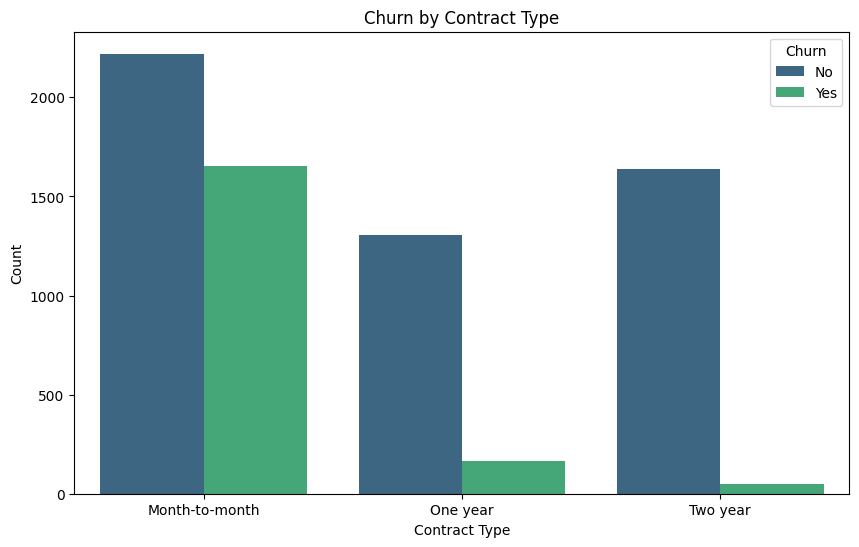

In [320]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x="Contract", hue="Churn", palette="viridis")
plt.title("Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Count")
plt.legend(title="Churn")
plt.show()

In [321]:
print(df.groupby("Contract")["Churn"].value_counts(normalize=True).unstack())

Churn                 No       Yes
Contract                          
Month-to-month  0.572903  0.427097
One year        0.887228  0.112772
Two year        0.971513  0.028487


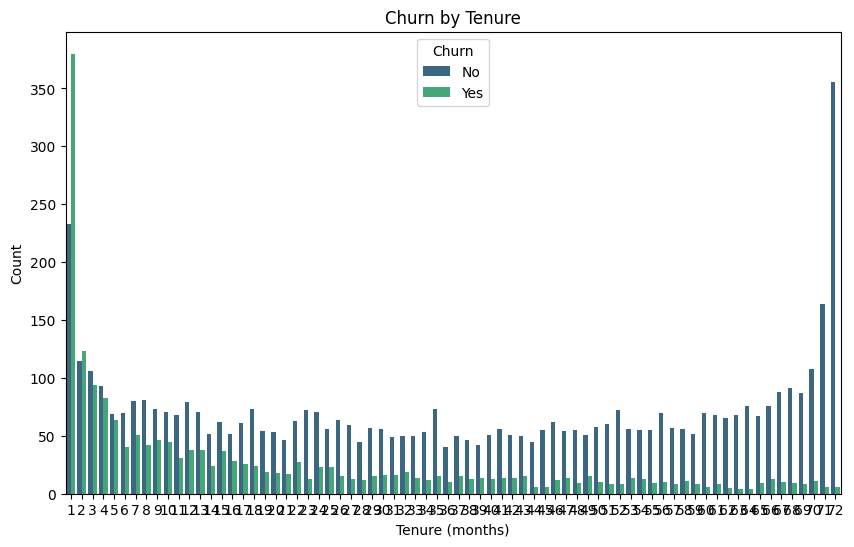

In [322]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x="tenure", hue="Churn", palette="viridis")
plt.title("Churn by Tenure")
plt.xlabel("Tenure (months)")
plt.ylabel("Count")
plt.legend(title="Churn")
plt.show()

In [323]:
print(df.groupby("tenure")["Churn"].value_counts(normalize=True).unstack())

Churn         No       Yes
tenure                    
1       0.380098  0.619902
2       0.483193  0.516807
3       0.530000  0.470000
4       0.528409  0.471591
5       0.518797  0.481203
...          ...       ...
68      0.910000  0.090000
69      0.915789  0.084211
70      0.907563  0.092437
71      0.964706  0.035294
72      0.983425  0.016575

[72 rows x 2 columns]


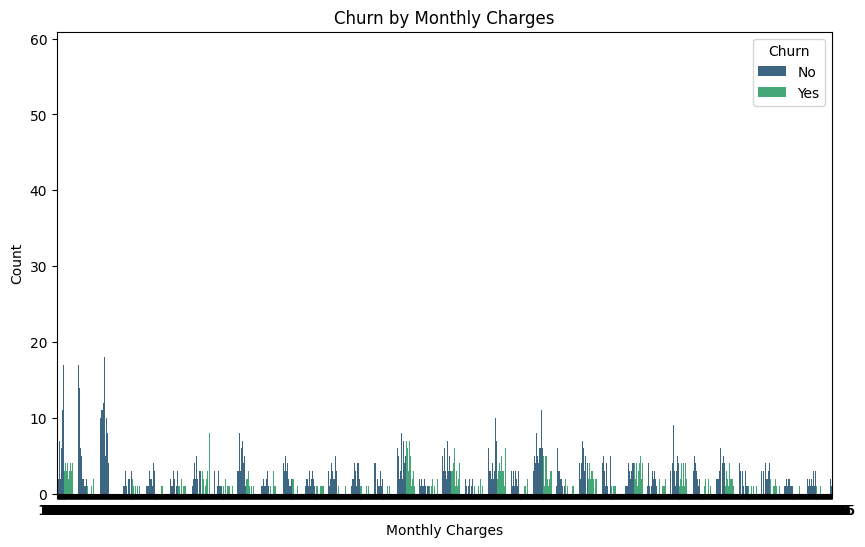

In [324]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x="MonthlyCharges", hue="Churn", palette="viridis")
plt.title("Churn by Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Count")
plt.legend(title="Churn")
plt.show()

In [325]:
df["Above_Median_Charges"] = df["MonthlyCharges"] > df["MonthlyCharges"].median()
print(df.groupby("Above_Median_Charges")["Churn"].value_counts(normalize=True).unstack())

Churn                       No       Yes
Above_Median_Charges                    
False                 0.820404  0.179596
True                  0.647879  0.352121


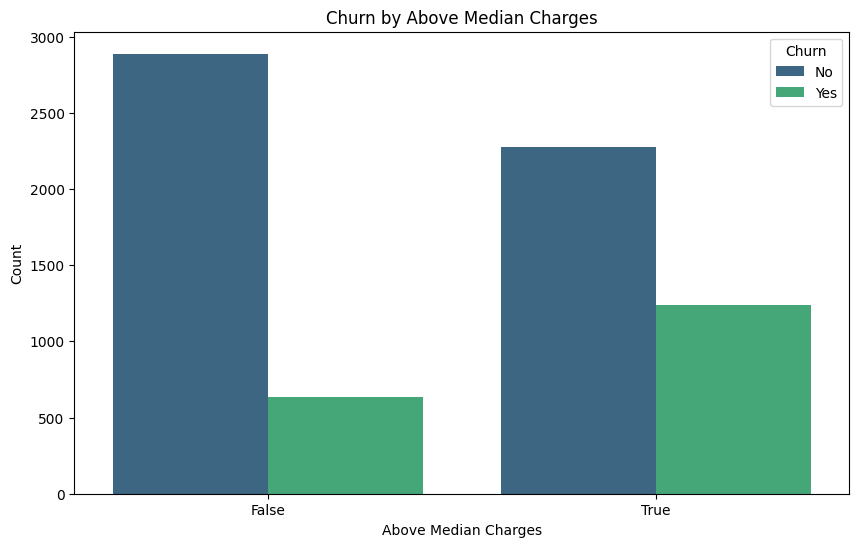

In [326]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x="Above_Median_Charges", hue="Churn", palette="viridis")
plt.title("Churn by Above Median Charges")
plt.xlabel("Above Median Charges")
plt.ylabel("Count")
plt.legend(title="Churn")

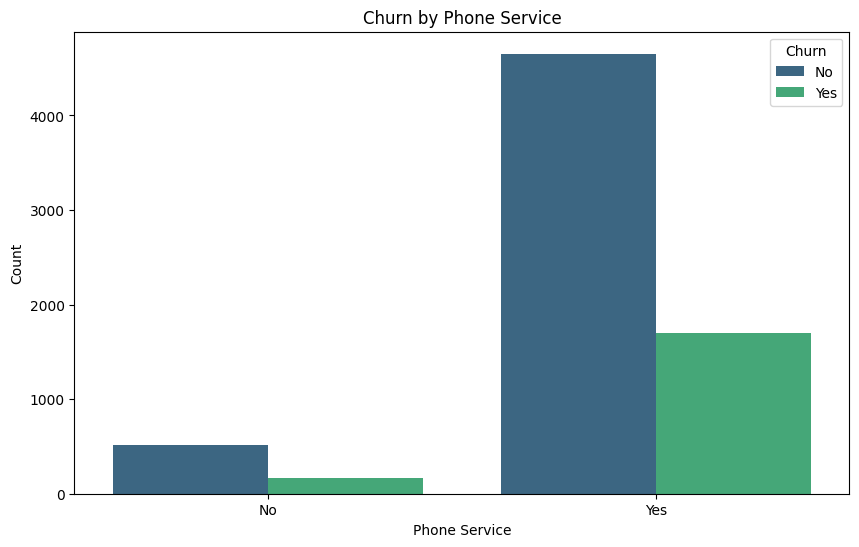

In [327]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x="PhoneService", hue="Churn", palette="viridis")
plt.title("Churn by Phone Service")
plt.xlabel("Phone Service")
plt.ylabel("Count")
plt.legend(title="Churn")

In [328]:
print(df.groupby('PhoneService')['Churn'].value_counts(normalize=True).unstack())

Churn               No       Yes
PhoneService                    
No            0.750000  0.250000
Yes           0.732525  0.267475


In [329]:
print(df.columns)

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn', 'Above_Median_Charges'],
      dtype='str')


In [330]:
colonnes_to_drop = df.columns[df.nunique() > 5].tolist() + ["Churn"]
print(colonnes_to_drop)
for col in colonnes_to_drop:
    if col == "TotalCharges":
        df[col] = df[col].astype(float)
    if col != "Churn" and col != "MonthlyCharges" and df[col].dtype != "string":
        print(f"Processing column: {col}")       
        df[f"{col}_median"] = df[col] < df[col].median()

print(df.columns)

['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']
Processing column: tenure
Processing column: TotalCharges
Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn', 'Above_Median_Charges',
       'tenure_median', 'TotalCharges_median'],
      dtype='str')


In [331]:

colonnes_to_check = df.select_dtypes(include=['object', 'bool','int64']).columns.drop(colonnes_to_drop, errors='ignore')
print(colonnes_to_check)

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'Above_Median_Charges',
       'tenure_median', 'TotalCharges_median'],
      dtype='str')


C:\Users\robin\AppData\Local\Temp\ipykernel_17592\656365938.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  colonnes_to_check = df.select_dtypes(include=['object', 'bool','int64']).columns.drop(colonnes_to_drop, errors='ignore')


In [332]:
for col in colonnes_to_check:
    print(df.groupby(col)['Churn'].value_counts(normalize=True).unstack())

Churn         No       Yes
gender                    
Female  0.730405  0.269595
Male    0.737954  0.262046
Churn                No       Yes
SeniorCitizen                    
0              0.763497  0.236503
1              0.583187  0.416813
Churn          No       Yes
Partner                    
No       0.670239  0.329761
Yes      0.802829  0.197171
Churn             No       Yes
Dependents                    
No          0.687209  0.312791
Yes         0.844688  0.155312
Churn               No       Yes
PhoneService                    
No            0.750000  0.250000
Yes           0.732525  0.267475
Churn                   No       Yes
MultipleLines                       
No                0.749188  0.250812
No phone service  0.750000  0.250000
Yes               0.713515  0.286485
Churn                  No       Yes
InternetService                    
DSL              0.810017  0.189983
Fiber optic      0.581072  0.418928
No               0.925658  0.074342
Churn                  

In [333]:
print(df.columns)

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn', 'Above_Median_Charges',
       'tenure_median', 'TotalCharges_median'],
      dtype='str')


So now 

Processing column: gender
Processing column: SeniorCitizen
Processing column: Partner
Processing column: Dependents
Processing column: PhoneService
Processing column: MultipleLines
Processing column: InternetService
Processing column: OnlineSecurity
Processing column: OnlineBackup
Processing column: DeviceProtection
Processing column: TechSupport
Processing column: StreamingTV
Processing column: StreamingMovies
Processing column: Contract
Processing column: PaperlessBilling
Processing column: PaymentMethod
Processing column: Above_Median_Charges
Processing column: tenure_median
Processing column: TotalCharges_median


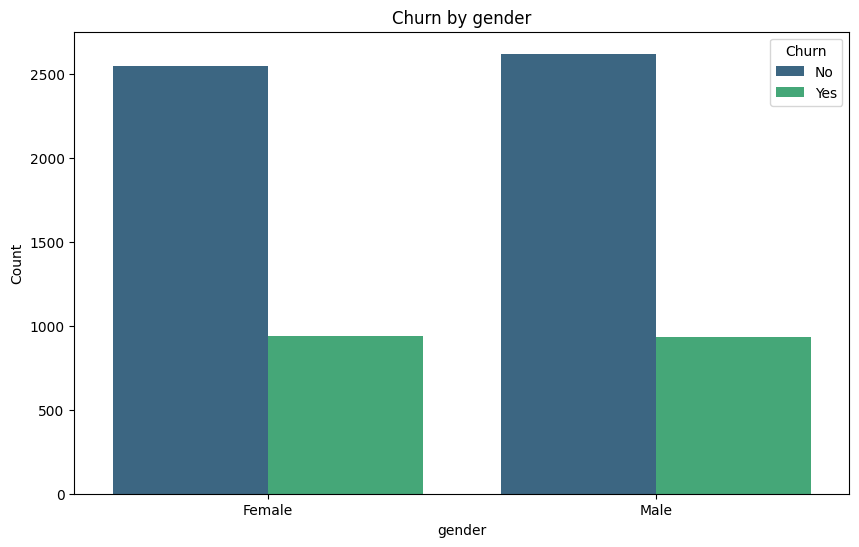

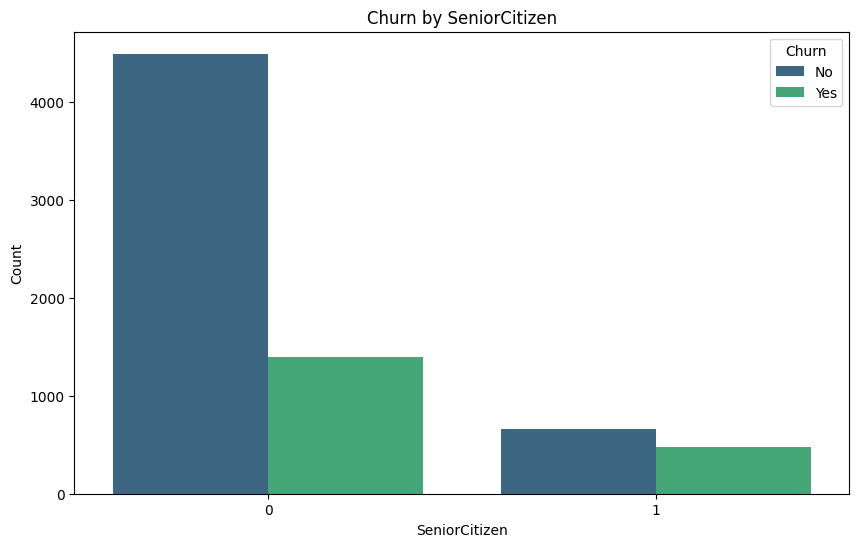

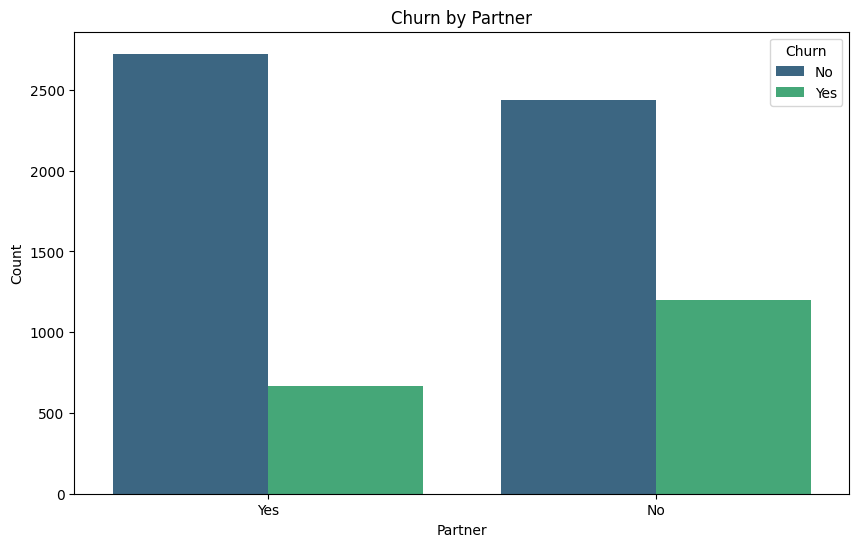

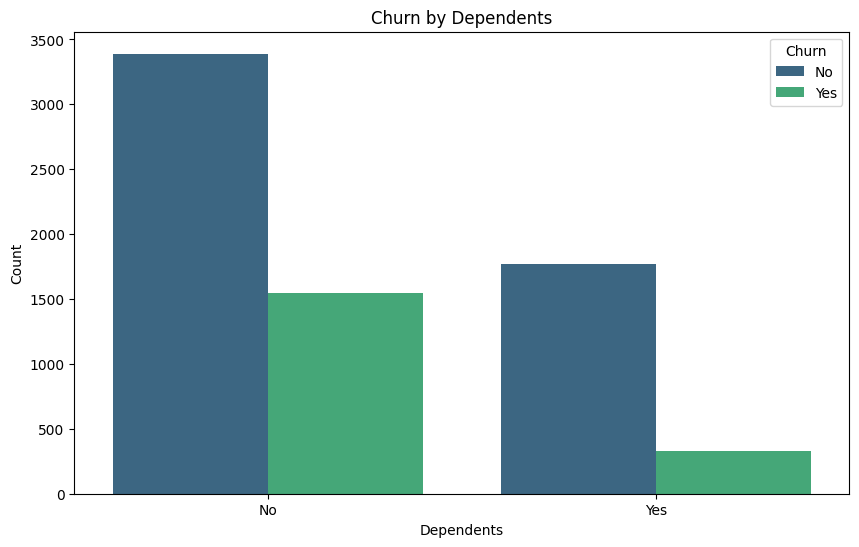

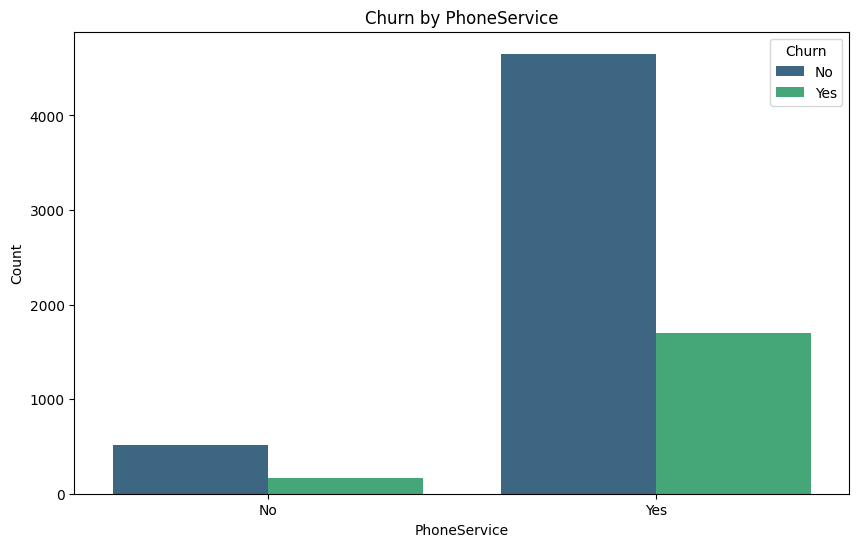

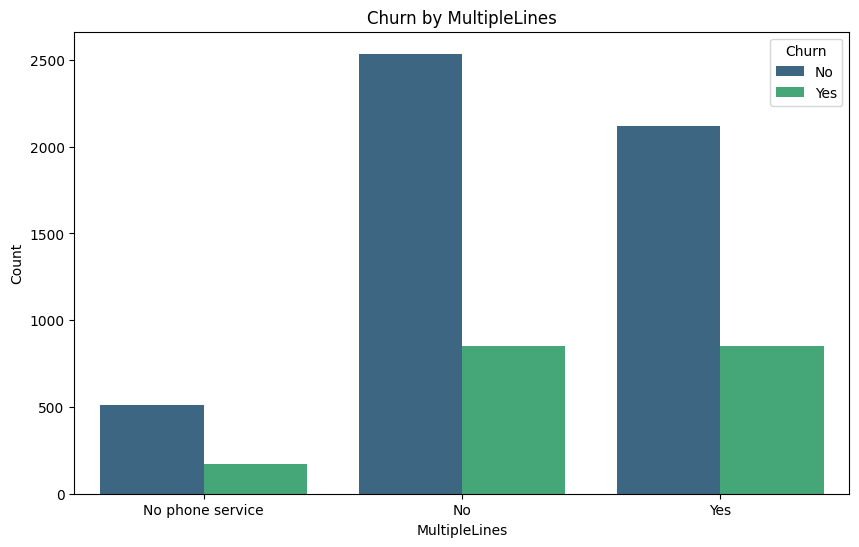

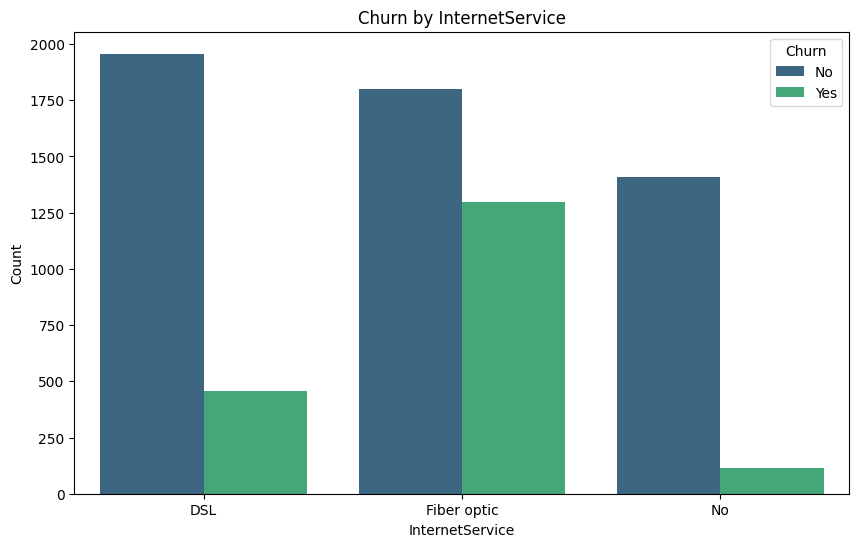

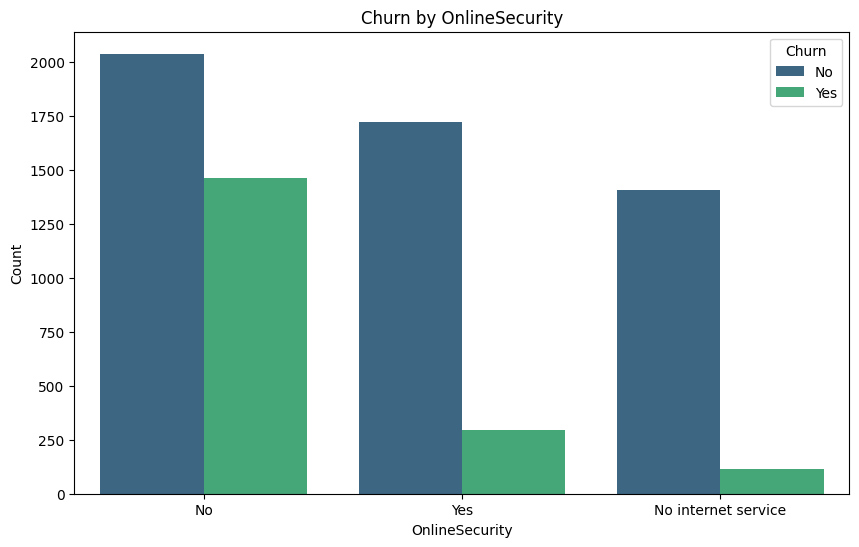

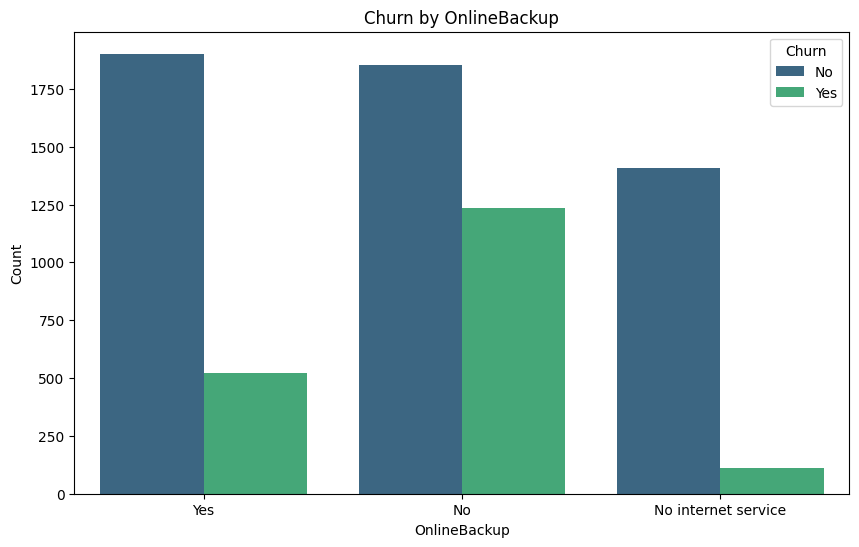

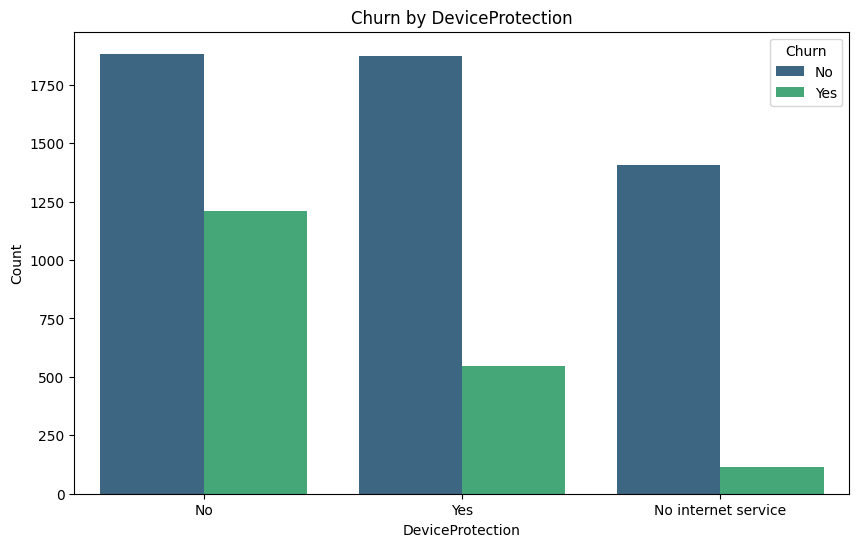

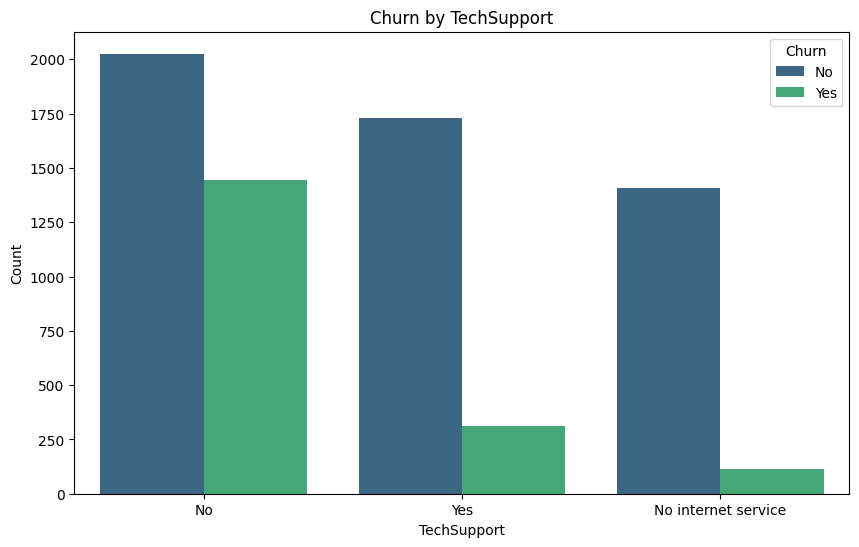

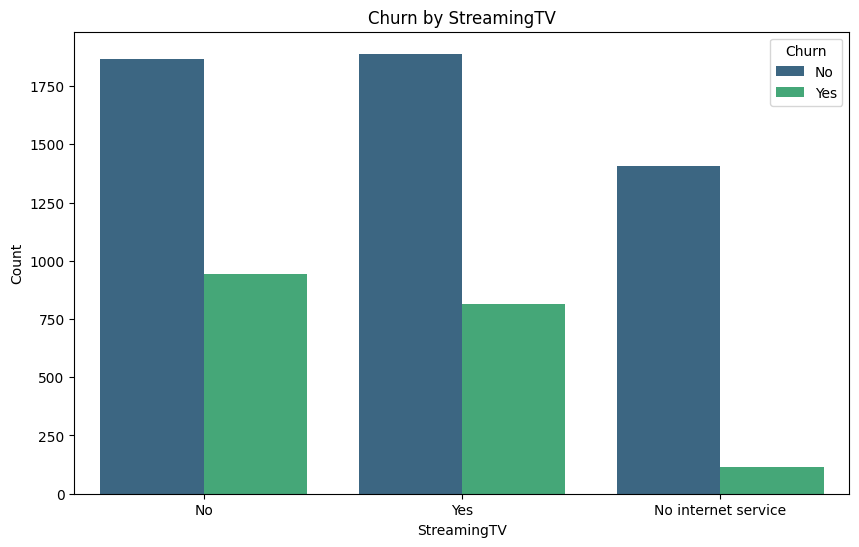

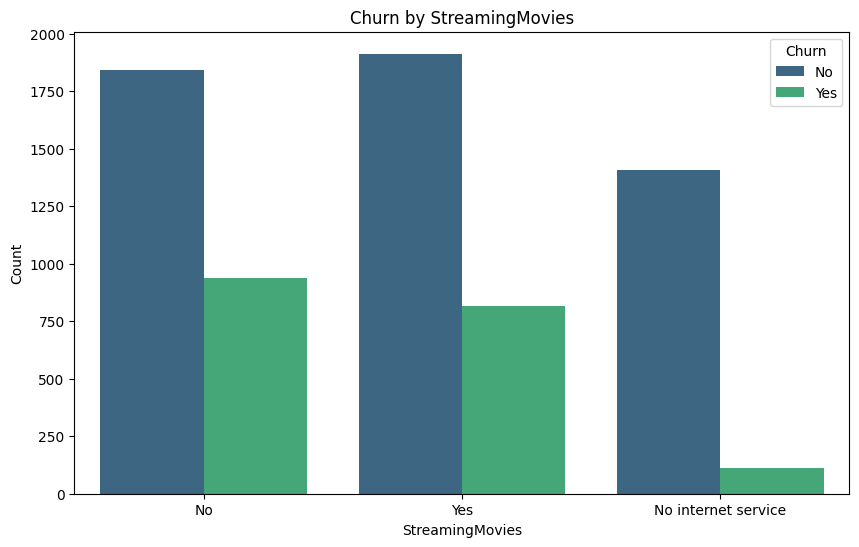

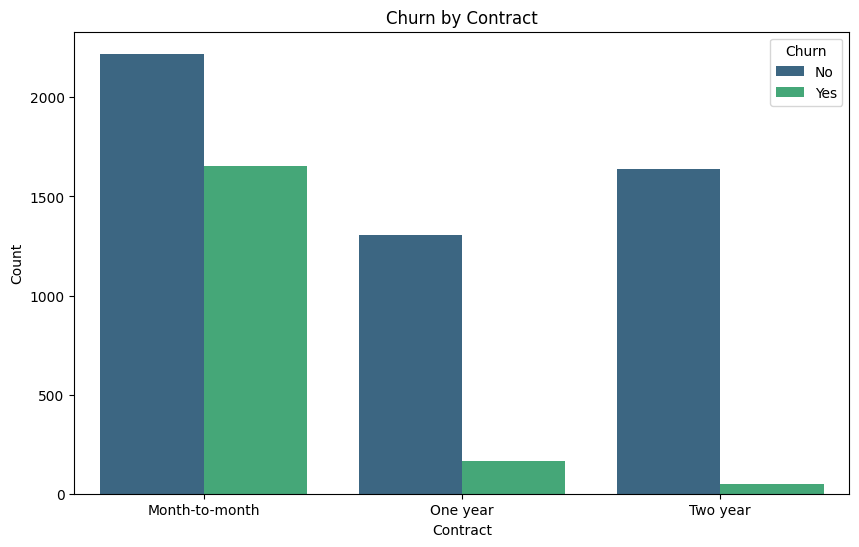

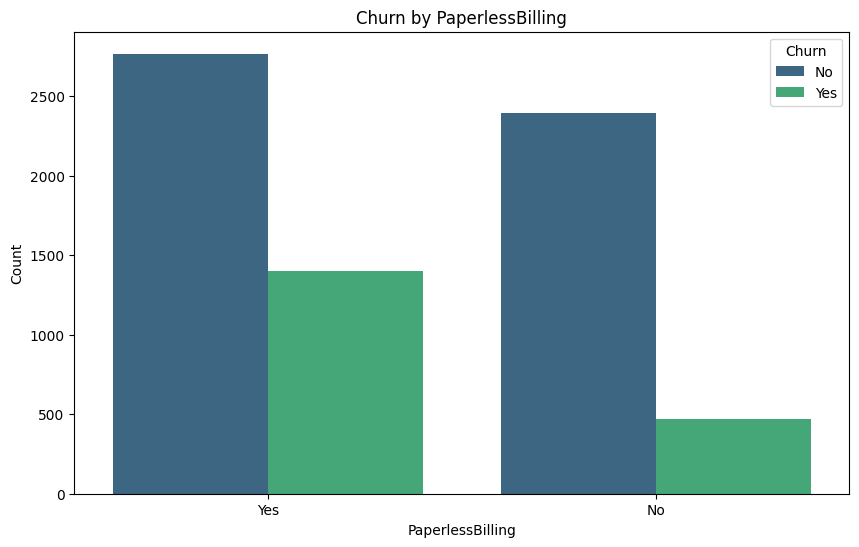

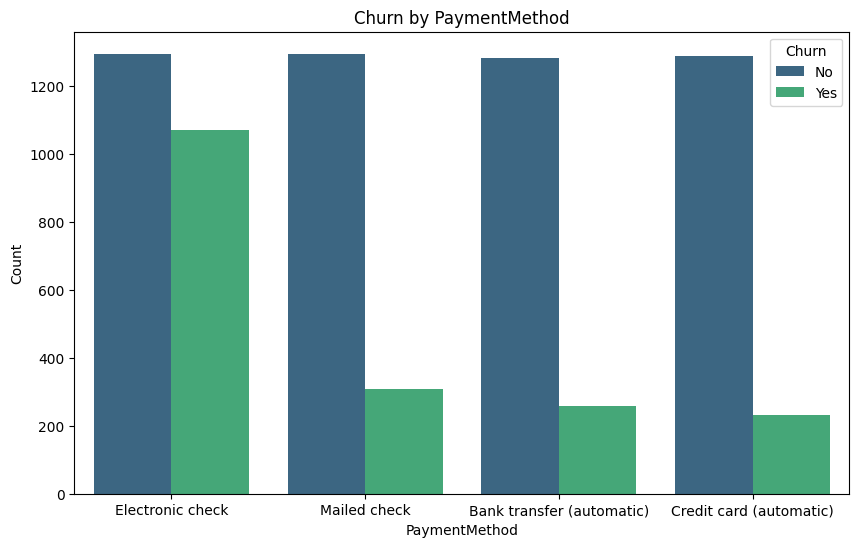

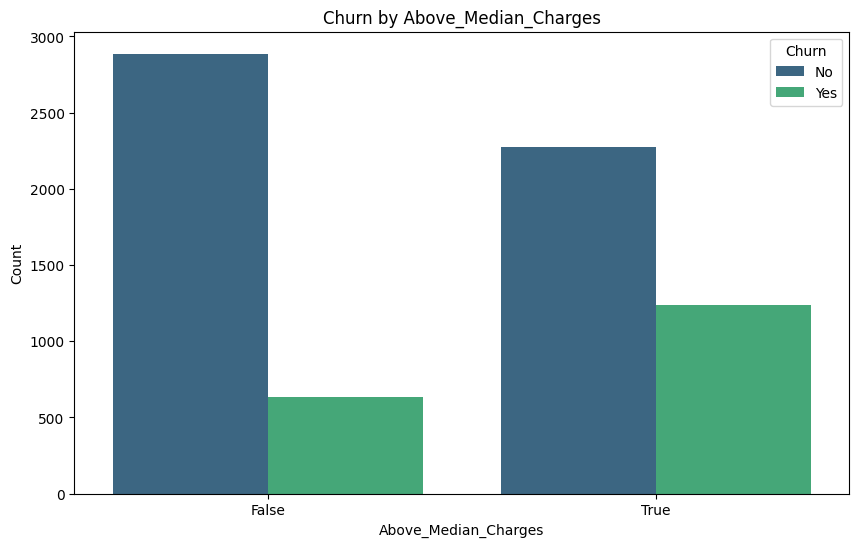

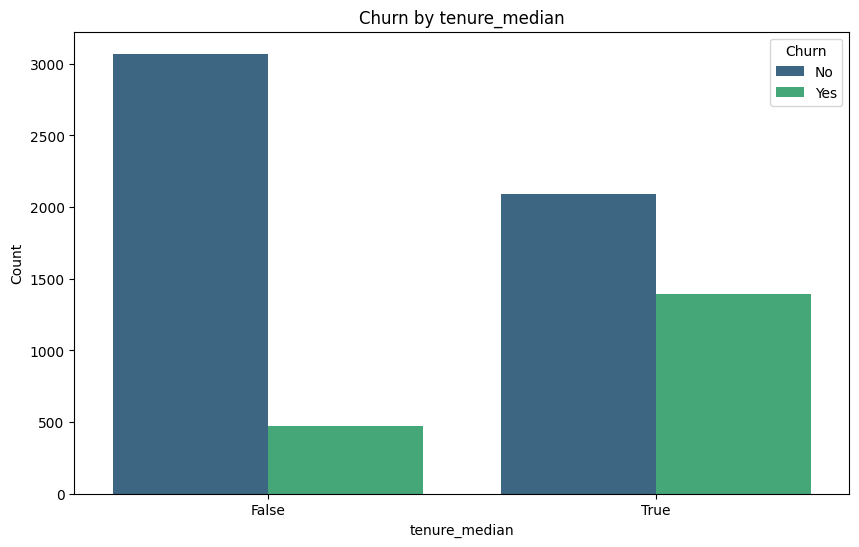

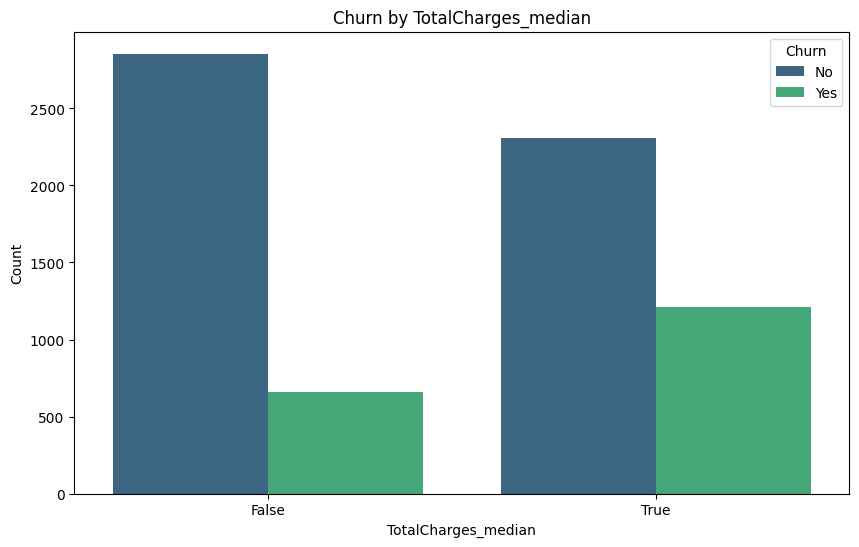

In [334]:
for col in colonnes_to_check:
    print(f"Processing column: {col}")
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x=col, hue="Churn", palette="viridis")
    plt.title(f"Churn by {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.legend(title="Churn")

Now that we have vizualised all the columns depends on churn we can see that some columns are better use to know if someone will quit or no.Let's keep this column :Tenure,Montlycharges,partner,dependant,contract,paymentmethod,paperlessBilling,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Total charges,SeniorCitizen                                                      

In [335]:
colonnes_to_keep = ["TotalCharges","tenure","MonthlyCharges","Partner","Dependents",
                    "Contract","PaymentMethod","PaperlessBilling","InternetService",
                    "OnlineSecurity","OnlineBackup","DeviceProtection","TechSupport",
                    "StreamingTV","StreamingMovies","SeniorCitizen","Churn"]

for col in df.columns:
    if col not in colonnes_to_keep:
        df.drop(columns=col, inplace=True)

print(df.columns)

Index(['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')


In [336]:
print(df.dtypes)

SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object


In [337]:
print(df.nunique())

SeniorCitizen          2
Partner                2
Dependents             2
tenure                72
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1584
TotalCharges        6530
Churn                  2
dtype: int64


In [338]:
for col in df.columns:
    print(f"Processing column: {col} : {df[col].unique()} unique values")

Processing column: SeniorCitizen : [0 1] unique values
Processing column: Partner : <StringArray>
['Yes', 'No']
Length: 2, dtype: str unique values
Processing column: Dependents : <StringArray>
['No', 'Yes']
Length: 2, dtype: str unique values
Processing column: tenure : [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26 39] unique values
Processing column: InternetService : <StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str unique values
Processing column: OnlineSecurity : <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str unique values
Processing column: OnlineBackup : <StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str unique values
Processing column: DeviceProtection : <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str unique values
Processin

Now let's encode every column before creating our AI

We have already encoded TotalCharge,MonthlyCharges,seniorCitizen because they are numerical column.
For the str column with 

In [ ]:
cols_to_encode = []

for col in df.select_dtypes(include=['object']).columns:
    if col == "Churn":
        continue
    
    if df[col].nunique() == 2:
        df[col] = df[col].map({'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0})
    
    else:
        cols_to_encode.append(col)

df_copy = df.copy()
df_copy = pd.get_dummies(df_copy, columns=cols_to_encode, drop_first=True)
df_copy['Churn'] = df_copy['Churn'].map({'Yes': 1, 'No': 0})
df_copy = df_copy.astype({col: 'int64' for col in df_copy.select_dtypes('bool').columns})
df_copy = df_copy.dropna()
df_copy.reset_index(drop=True)
print(df_copy.nunique())
print(df_copy.dtypes)



df_copy2 = df.copy()
df_copy2['Charges_per_Month'] = df_copy2['TotalCharges'] / (df_copy2['tenure'] + 1)
df_copy2['Service_Count'] = df_copy2[['OnlineSecurity', 'OnlineBackup', 'DeviceProtection','TechSupport', 'StreamingTV', 'StreamingMovies']].apply(lambda x: (x == 'Yes').sum(), axis=1)
df_copy2 = pd.get_dummies(df_copy2, columns=cols_to_encode, drop_first=True)
df_copy2['Churn'] = df_copy2['Churn'].map({'Yes': 1, 'No': 0})
df_copy2 = df_copy2.astype({col: 'int64' for col in df_copy2.select_dtypes('bool').columns})
df_copy2 = df_copy2.dropna()
df_copy2.reset_index(drop=True)

print(df_copy2.nunique())
print(df_copy2.dtypes)

SeniorCitizen                               2
Partner                                     2
Dependents                                  2
tenure                                     72
PaperlessBilling                            2
MonthlyCharges                           1584
TotalCharges                             6530
Churn                                       2
InternetService_Fiber optic                 2
InternetService_No                          2
OnlineSecurity_No internet service          2
OnlineSecurity_Yes                          2
OnlineBackup_No internet service            2
OnlineBackup_Yes                            2
DeviceProtection_No internet service        2
DeviceProtection_Yes                        2
TechSupport_No internet service             2
TechSupport_Yes                             2
StreamingTV_No internet service             2
StreamingTV_Yes                             2
StreamingMovies_No internet service         2
StreamingMovies_Yes               

C:\Users\robin\AppData\Local\Temp\ipykernel_17592\490281828.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include=['object']).columns:


Now that we have encoded all the column let's now programm an AI to predit whether if someone will churn or not

In [ ]:

y = df_copy["Churn"]
X = df_copy.drop(columns=["Churn"])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set : {X_train.shape}")
print(f"Test set : {X_test.shape}")


Training set : (5625, 26)
Test set : (1407, 26)


In [341]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("Accuracy Score:")
print(accuracy_score(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.49      0.55       374

    accuracy                           0.78      1407
   macro avg       0.72      0.69      0.70      1407
weighted avg       0.77      0.78      0.78      1407

Confusion Matrix:
[[919 114]
 [189 185]]
Accuracy Score:
0.7846481876332623


The resulat are good for a first but it can be better

C:\Users\robin\AppData\Local\Temp\ipykernel_17592\3668524642.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=features_importance_df,palette="magma")


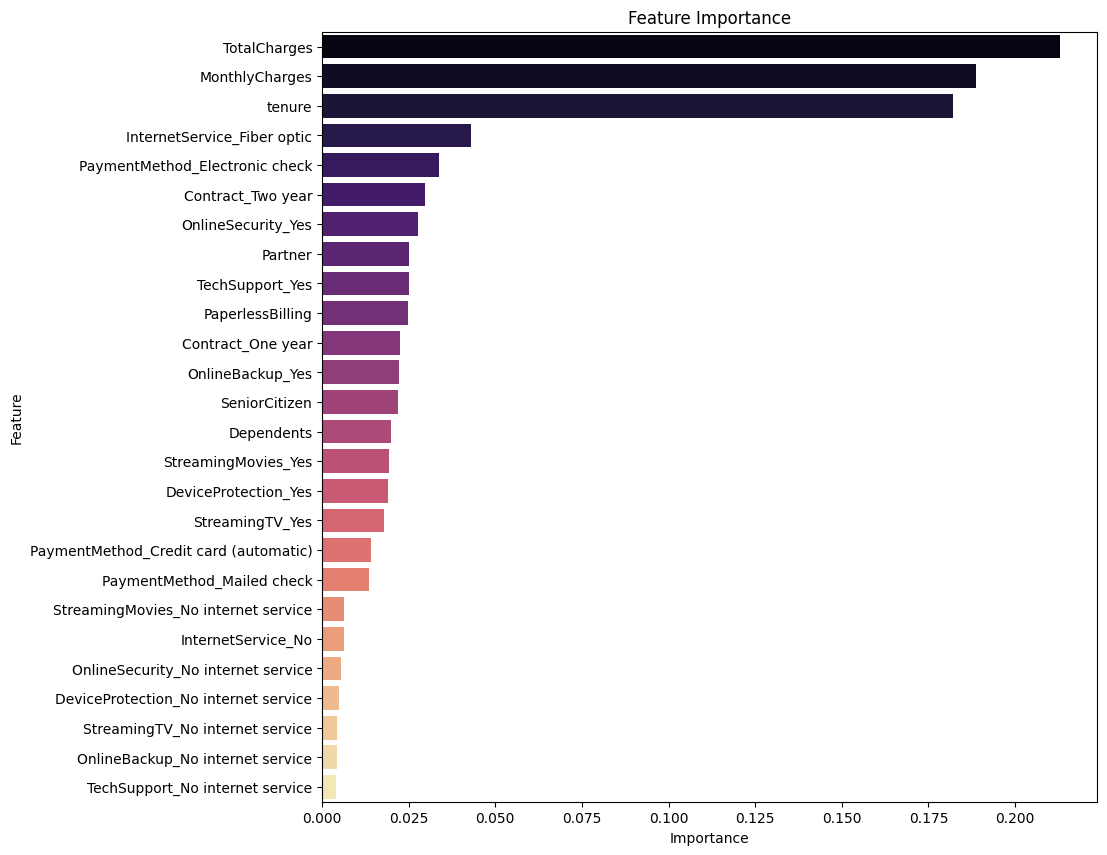

In [342]:
importance = model.feature_importances_
features_importance = X.columns
features_importance_df = pd.DataFrame({'Feature': features_importance, 'Importance': importance})
features_importance_df = features_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 10))
sns.barplot(x='Importance', y='Feature', data=features_importance_df,palette="magma")
plt.title("Feature Importance")
plt.show()

The feature importance shows us that all our features are usefull.So let's stick with that.
We have seen that the model has a bigger difficulty to predict people that will leave.

Up-sampling

In [343]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

model_smote = RandomForestClassifier(n_estimators=100, random_state=42)
model_smote.fit(X_train_res, y_train_res)

y_pred_v2 = model_smote.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred_v2))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_v2))

print("Accuracy Score:")
print(accuracy_score(y_test, y_pred_v2))

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.82      0.83      1033
           1       0.54      0.58      0.56       374

    accuracy                           0.76      1407
   macro avg       0.69      0.70      0.70      1407
weighted avg       0.76      0.76      0.76      1407

Confusion Matrix:
[[850 183]
 [158 216]]
Accuracy Score:
0.757640369580668


Boosting : if the model can't better, there are other model that can be tested

In [344]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)
xgb_model.fit(X_train_res, y_train_res)
y_probs = xgb_model.predict_proba(X_test)[:, 1]
y_pred_custom = (y_probs > 0.7).astype(int)
print("Classification Report:")
print(classification_report(y_test, y_pred_custom))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_custom))

print("Accuracy Score:")
print(accuracy_score(y_test, y_pred_custom))

c:\Users\robin\programmation\IA\churn_rate\env_churn\Lib\site-packages\xgboost\training.py:200: UserWarning: [00:01:44] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.91      0.86      1033
           1       0.62      0.41      0.50       374

    accuracy                           0.78      1407
   macro avg       0.72      0.66      0.68      1407
weighted avg       0.76      0.78      0.76      1407

Confusion Matrix:
[[938  95]
 [219 155]]
Accuracy Score:
0.7768301350390903


In [ ]:

y = df_copy2["Churn"]
X = df_copy2.drop(columns=["Churn"])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set : {X_train.shape}")
print(f"Test set : {X_test.shape}")

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("Accuracy Score:")
print(accuracy_score(y_test, y_pred))


importance = model.feature_importances_
features_importance = X.columns
features_importance_df = pd.DataFrame({'Feature': features_importance, 'Importance': importance})
features_importance_df = features_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 10))
sns.barplot(x='Importance', y='Feature', data=features_importance_df,palette="magma")
plt.title("Feature Importance")
plt.show()

from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

model_smote = RandomForestClassifier(n_estimators=100, random_state=42)
model_smote.fit(X_train_res, y_train_res)

y_pred_v2 = model_smote.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred_v2))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_v2))

print("Accuracy Score:")
print(accuracy_score(y_test, y_pred_v2))

from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)
xgb_model.fit(X_train_res, y_train_res)
y_probs = xgb_model.predict_proba(X_test)[:, 1]
y_pred_custom = (y_probs > 0.7).astype(int)
print("Classification Report:")
print(classification_report(y_test, y_pred_custom))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_custom))

print("Accuracy Score:")
print(accuracy_score(y_test, y_pred_custom))

KeyError: "None of [Index(['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',\n       'StreamingTV', 'StreamingMovies'],\n      dtype='str')] are in the [columns]"